In [20]:
import pandas as pd
df1 = pd.read_excel('_h_batch_process_data.xlsx')
df2 = pd.read_excel('_h_batch_production_data.xlsx')


In [39]:
augmented_data = pd.read_csv('synthetic_process_data.csv')
augmented_data = augmented_data.loc[:, augmented_data.nunique() > 1]

In [40]:
augmented_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Moisture_Content      10000 non-null  float64
 1   Tablet_Weight         10000 non-null  float64
 2   Hardness              10000 non-null  float64
 3   Friability            10000 non-null  float64
 4   Disintegration_Time   10000 non-null  float64
 5   Dissolution_Rate      10000 non-null  float64
 6   Content_Uniformity    10000 non-null  float64
 7   Time_Minutes          10000 non-null  float64
 8   Temperature_C         10000 non-null  float64
 9   Pressure_Bar          10000 non-null  float64
 10  Humidity_Percent      10000 non-null  float64
 11  Motor_Speed_RPM       10000 non-null  float64
 12  Compression_Force_kN  10000 non-null  float64
 13  Flow_Rate_LPM         10000 non-null  float64
 14  Power_Consumption_kW  10000 non-null  float64
 15  Vibration_mm_s      

In [42]:
# augmented_data["Process_Intensity"] = augmented_data["Drying_Temp"] * augmented_data["Drying_Time"]

# augmented_data["Mechanical_Load"] = augmented_data["Compression_Force"] * augmented_data["Machine_Speed"]

# augmented_data["Binder_Ratio"] = augmented_data["Binder_Amount"] / augmented_data["Granulation_Time"]

In [44]:
# augmented_data.drop('Batch_ID',axis=1,inplace=True)

In [45]:
# augmented_data["Lubricant_Conc"] = augmented_data["Lubricant_Conc"].clip(lower=0)
# augmented_data["Moisture_Content"] = augmented_data["Moisture_Content"].clip(lower=0)
# augmented_data["Friability"] = augmented_data["Friability"].clip(lower=0)
# augmented_data["Disintegration_Time"] = augmented_data["Disintegration_Time"].clip(lower=0)

In [46]:
X = augmented_data.drop(['Hardness','Content_Uniformity','Dissolution_Rate','Tablet_Weight','Friability','Disintegration_Time'],axis=1)
y = augmented_data[['Hardness','Content_Uniformity','Dissolution_Rate','Tablet_Weight','Friability','Disintegration_Time']]

<Axes: >

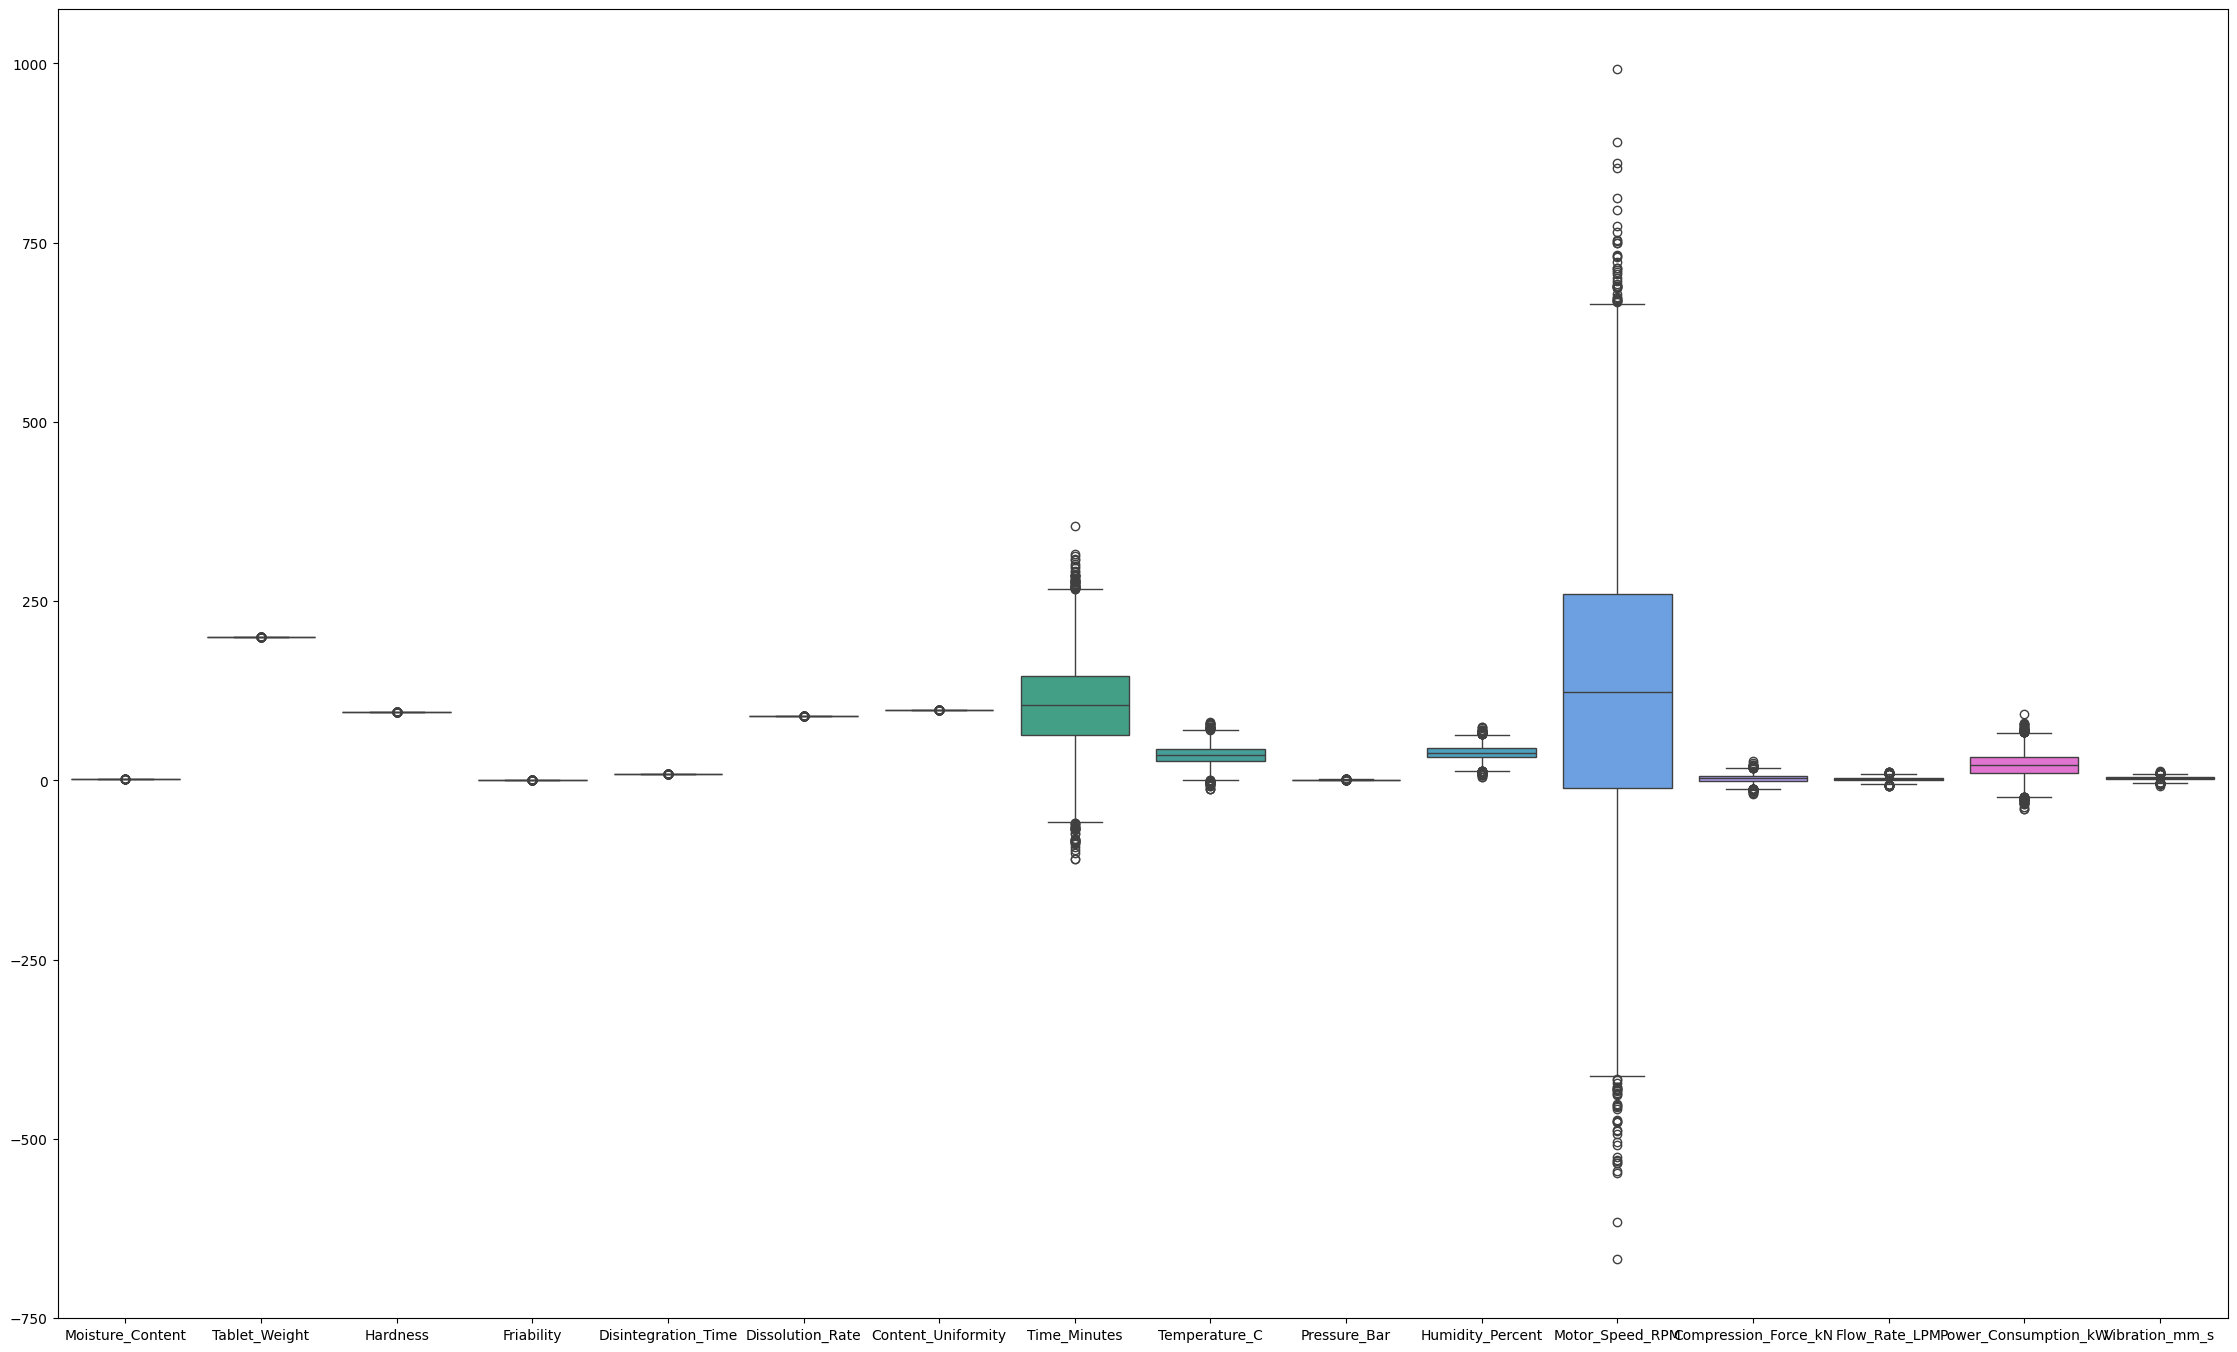

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(28,17))
sns.boxplot(augmented_data)

In [48]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [49]:
X_train.shape

(8000, 10)

In [50]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

models = {
    "RandomForest": MultiOutputRegressor(RandomForestRegressor(random_state=42)),
    "XGBoost": MultiOutputRegressor(XGBRegressor(random_state=42)),
    "GradientBoosting": MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
    "SVR": MultiOutputRegressor(SVR())
}

In [52]:
param_grids = {

"RandomForest": {
    "estimator__n_estimators":[200,400,600],
    "estimator__max_depth":[8,12,16],
    "estimator__min_samples_split":[2,5,10],
    "estimator__min_samples_leaf":[1,2,4]
},

"XGBoost": {
    "estimator__n_estimators":[300,500,700],
    "estimator__max_depth":[4,6,8],
    "estimator__learning_rate":[0.01,0.03,0.05],
    "estimator__subsample":[0.7,0.8,0.9]
},

"GradientBoosting": {
    "estimator__n_estimators":[200,400,600],
    "estimator__learning_rate":[0.01,0.05,0.1],
    "estimator__max_depth":[3,5,7]
},

"SVR": {
    "estimator__kernel":["rbf"],
    "estimator__C":[10,50,100],
    "estimator__epsilon":[0.01,0.1,0.2]
}
}

In [53]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

results = []

for name, model in models.items():

    search = RandomizedSearchCV(
        model,
        param_grids[name],
        n_iter=10,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    pred = best_model.predict(X_test)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

d:\Ml Model\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=10. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [54]:
results_df = pd.DataFrame(results)

print(results_df.sort_values("R2", ascending=False))

              Model        R2           MAE          RMSE
1           XGBoost  0.833209  2.467632e-08  3.454139e-07
0      RandomForest -0.000591  2.786647e-07  7.019957e-07
2  GradientBoosting -0.003756  2.790126e-07  7.032320e-07
3               SVR -0.038727  2.947936e-07  7.517240e-07


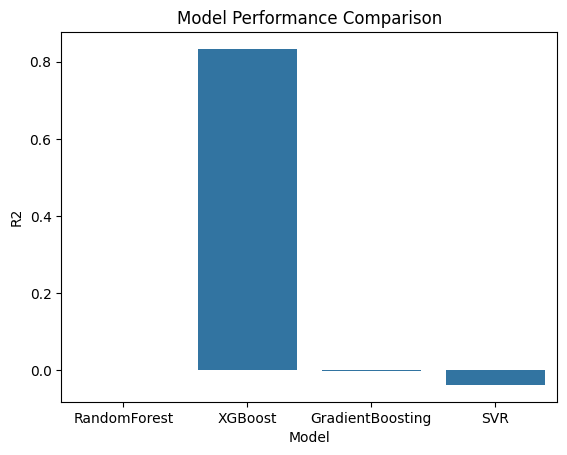

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="R2", data=results_df)

plt.title("Model Performance Comparison")
plt.show()

In [56]:
augmented_data.nunique().sort_values()

Moisture_Content           29
Content_Uniformity       9933
Hardness                 9997
Dissolution_Rate         9998
Friability              10000
Tablet_Weight           10000
Disintegration_Time     10000
Time_Minutes            10000
Temperature_C           10000
Pressure_Bar            10000
Humidity_Percent        10000
Motor_Speed_RPM         10000
Compression_Force_kN    10000
Flow_Rate_LPM           10000
Power_Consumption_kW    10000
Vibration_mm_s          10000
dtype: int64

In [57]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(14,10))

# corr_matrix = augmented_data.corr(numeric_only=True)

# sns.heatmap(
#     corr_matrix,
#     cmap="coolwarm",
#     annot=True,
#     fmt=".2f",
#     linewidths=0.5
# )

# plt.title("Feature Correlation Heatmap")
# plt.show()

In [58]:
augmented_data.nunique()

Moisture_Content           29
Tablet_Weight           10000
Hardness                 9997
Friability              10000
Disintegration_Time     10000
Dissolution_Rate         9998
Content_Uniformity       9933
Time_Minutes            10000
Temperature_C           10000
Pressure_Bar            10000
Humidity_Percent        10000
Motor_Speed_RPM         10000
Compression_Force_kN    10000
Flow_Rate_LPM           10000
Power_Consumption_kW    10000
Vibration_mm_s          10000
dtype: int64